In [1]:
import os, sys, multiprocessing, pickle
from tqdm import tqdm
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import cv2
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sys.path.append("/DATA/F2FMatcher_DDC")
from config.ddc_config import *
from collections import abc

In [2]:
fs_mask = [
    'area','perimeter','bbox_height', 'bbox_width', 'bbox_aspect_ratio',
    'eccentricity','solidity','extent','major_axis_length','minor_axis_length',
    'orientation','roundness','edge_pixels','edge_density','compactness'
]
fs_intensity = ['mean', 'std', 'p10', 'p25', 'p50', 'p75', 'p90', 'skew', 'kurt']

In [3]:
def get_filename(name_sample, list_names):
    names = [n for n in list_names if name_sample.upper() in n.upper()]
    if len(names)==0:
        print(f'No image of sample {name_sample} found.')
        return None
    else:
        name = names[0].split(".")[0]
        return name
    
# get all images
dict_all_images = {"TA": {}, "QUA": {}}
dict_img2metadata = {"TA": {}, "QUA": {}}

for muscle in ["TA", "QUA"]:
    dir_czi_source = CZI_BASE_DIR_TA if muscle == "TA" else CZI_BASE_DIR_QUA
    dir_CP_MASKS = CP_MASKS_DIR_TA if muscle == "TA" else CP_MASKS_DIR_QUA
    dir_pair_output = PAIR_DIRS_BASE_TA if muscle == "TA" else PAIR_DIRS_BASE_QUA
    list_samples = TA_SAMPLES if muscle == "TA" else QUA_SAMPLES
    
    for sample in list_samples:
        dict_all_images[muscle][sample] = {}
        for slide in SLIDES.keys():
            list_images = [f.split(".czi")[0] for f in os.listdir(dir_czi_source / f'{SLIDES[slide]["czi_dir"]}') \
                            if f.endswith(".czi")]
            img = get_filename(sample, list_images)
            dict_all_images[muscle][sample][slide] = img
            dict_img2metadata[muscle][img] = {"sample": sample, "slide": slide}

list_features = [f"M_{f}" for f in fs_mask]
for slide in SLIDES.keys():    
    list_channels = SLIDES[slide]["stainings"].keys()
    # concatenate features intensity across channel
    for channel in list_channels:
        for compartement in range(4):
            list_features.extend([f"I_sl{slide}_ch{channel}_c{compartement}_{f}" for f in fs_intensity])

assert len(list_features) == 15+36*18

In [4]:
def load_features(sample, muscle):
    features_dir = f"/DATA/F2FMatcher_DDC/results/{muscle}/features_combined"
    pickle_path = f"{features_dir}/{sample}.pkl"
    with open(pickle_path, "rb") as f:
        features_dict = pickle.load(f)
    df = pd.DataFrame.from_dict(features_dict, orient='index', dtype=np.float64)
    df.index.name = 'label_id'
    if len(df.columns) != 663:
        raise ValueError(f"Expected 663 features, got {len(df.columns)}")
    df.columns = list_features
    df = pd.concat([
        pd.DataFrame({
            "sample": [sample] * df.shape[0],
            "group": [GROUP_OF_SAMPLE[sample]] * df.shape[0],
        }),
        df.reset_index()
    ], axis=1)
    return df

In [5]:
muscle = "TA"
list_samples = TA_SAMPLES if muscle == "TA" else QUA_SAMPLES

df_all = []
for sample in list_samples:
    df = load_features(sample, muscle)
    df = df.dropna()
    df_all.append(df)

df_all = pd.concat(df_all, axis=0, ignore_index=True)

In [15]:
features_to_plot = [f"M_{f}" for f in fs_mask]

for slide in [1,2]:    
    list_channels = SLIDES[slide]["stainings"].keys()
    for f in ['mean', 'std', 'p10', 'p25', 'p50', 'p75', 'p90', 'skew', 'kurt']:
        for channel in list_channels:
            for compartement in [0,1,2,3]:
                features_to_plot.append(f"I_sl{slide}_ch{channel}_c{compartement}_{f}")

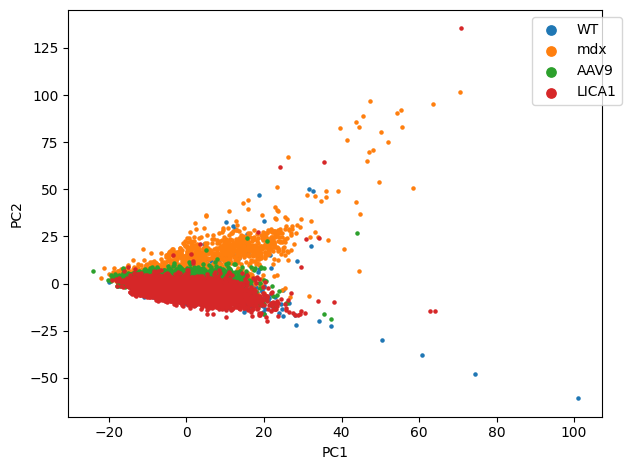

In [16]:
X = df_all[features_to_plot].to_numpy()
df_meta = df_all[["group"]]

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["sample"] = df_meta["group"].values

plt.figure()
for s in df_pca["sample"].unique():
    idx = df_pca["sample"] == s
    plt.scatter(df_pca.loc[idx, "PC1"],
                df_pca.loc[idx, "PC2"],
                label=s,
                s=5, alpha=1)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1))
plt.tight_layout()
# plt.xlim(-25,40)
# plt.ylim(-10,10)
plt.show()

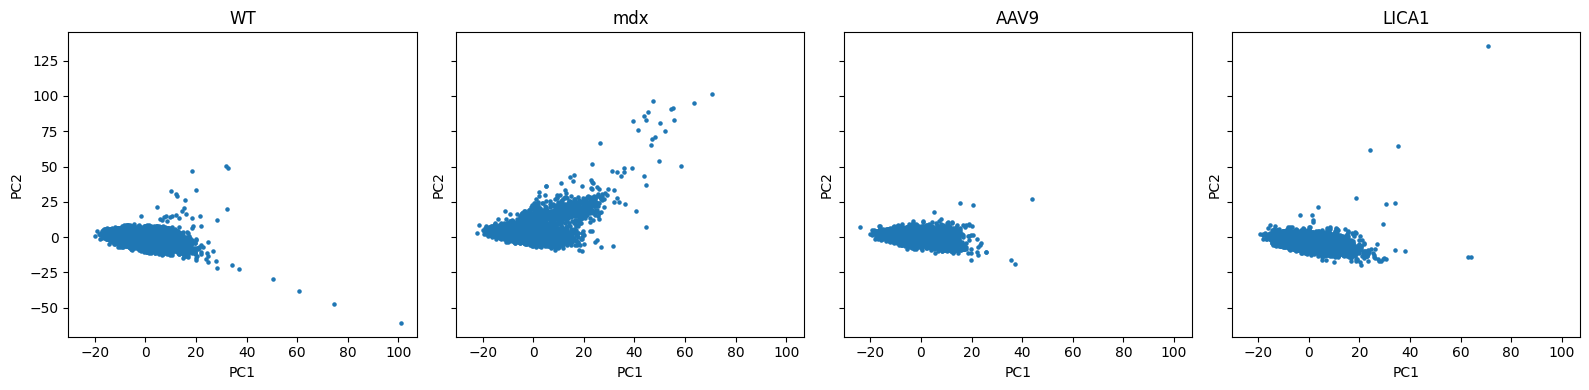

In [17]:
groups = df_pca["sample"].unique()
n_groups = len(groups)

fig, axes = plt.subplots(
    1, n_groups,
    figsize=(4 * n_groups, 4),
    sharex=True,
    sharey=True
)

# If only one group, axes is not iterable
if n_groups == 1:
    axes = [axes]

for ax, group in zip(axes, groups):
    idx = df_pca["sample"] == group
    ax.scatter(df_pca.loc[idx, "PC1"], df_pca.loc[idx, "PC2"], s=5)
    ax.set_title(group)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()